<a href="https://colab.research.google.com/github/VinceGarcia11/Melbourne_Housing/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [269]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.tools.tools as stattools
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.tools.tools as stattools
from sklearn.ensemble import RandomForestRegressor

#reading the data
url = "https://raw.githubusercontent.com/VinceGarcia11/Melbourne_Housing/refs/heads/main/melb_data.csv"
house = pd.read_csv(url)
house.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/3/2017,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


To prepare the data for a regression analysis and classification modeling, the superfluous variables needed to be dropped, categorical variables encoded, and empty values to be filled.

In [270]:
#X
h = house.drop(['Address', 'Method', 'SellerG', 'Postcode'], axis=1)
h1 = pd.get_dummies( h, drop_first=True)
# Replacing NaN values with 0
X =  h1.fillna(0)


The test-train split will be 80% Training, 20% Testing.



In [271]:
from sklearn.model_selection import train_test_split

#categorical variable
#Create a random 80/20 split
#creating the split
x_train, x_test = train_test_split(X, test_size = 0.20, random_state = 42)

In order to run any model, the train and test data needs to have the same number of columns.

In [272]:
print(x_train.shape)
print(x_test.shape)


(10864, 423)
(2716, 423)


Target Variable Chosen will be the Price of each house.

In [273]:
#Target Variable
y_train = x_train['Price']
#Target Variable
y_test = x_test['Price']

print(y_train.shape)
print(y_test.shape)

(10864,)
(2716,)


The regression will be done by an ensemble method, Random Forest.

In [274]:
rf01 = RandomForestRegressor(n_estimators = 100, min_samples_leaf = 10, max_depth = 5).fit(x_train, y_train)
predict = rf01.predict(x_test)

The Mean Absolute Error is calculated to predict the accuracy of the regression model.

In [275]:
from sklearn.metrics import mean_absolute_error as mae
error = mae(y_test, predict)
print("Mean absolute error : " + str(error))
#source: https://www.geeksforgeeks.org/python/how-to-calculate-mean-absolute-error-in-python/

Mean absolute error : 11600.266451586995


The Mean Absolute Error is roughly 12,200 AUD.
Given an accurate regression model, the classification method will be based on the region of each house. We expected the regions to have a significant impact on the price of the homes in Melbourne. For this reason, the price per square footage was calculated and grouped by region in order to gain more insight on which regions of Melbourne are more affluent.

In [276]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predict)
print('r2 score for perfect model is', r2)
#https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/

r2 score for perfect model is 0.9989490411067683


The R^2 value is 0.9989, which shows that this regression can be trusted with a high degree of confidence

In [277]:
# Create price/sq.ft. feature
house['price_per_sqft'] = house['Price'] / house['BuildingArea']

house = house.dropna(subset=['Price', 'BuildingArea', 'Regionname'])
house = house[house['BuildingArea'] > 0]

print(house.groupby('Regionname')['price_per_sqft'].describe())

                             count          mean           std          min  \
Regionname                                                                    
Eastern Metropolitan         708.0   9574.485161  33273.813628   188.484759   
Eastern Victoria              30.0   4517.782284   1589.979568   786.618445   
Northern Metropolitan       2090.0  12299.391950  52770.260581   261.382799   
Northern Victoria             28.0   3625.640609   1664.691556    30.439178   
South-Eastern Metropolitan   220.0   7701.725874  19814.806803   853.766617   
Southern Metropolitan       2409.0  14789.484298  89030.060858   474.695708   
Western Metropolitan        1607.0   8234.273167  20521.138092   707.142857   
Western Victoria              21.0   4061.400197   3443.223692  1600.000000   

                                    25%          50%           75%  \
Regionname                                                           
Eastern Metropolitan        5416.666667  6614.593230   8271.926338   

From the Results above, the Northern and Southern Metropolitan areas maintain the highest mean price per square footage, along with a much higher proportion of the homes in this dataset. If this dataset represents all of the homes available in Melbourne, then the regions with the higher counts have a higher urban density seems to be an indicator of higher prices.

In [278]:
homes = house.groupby('Regionname')['Regionname'].value_counts()
urban_density = homes / homes.sum()

In [279]:
print(urban_density)

Regionname
Eastern Metropolitan          0.099536
Eastern Victoria              0.004218
Northern Metropolitan         0.293828
Northern Victoria             0.003936
South-Eastern Metropolitan    0.030929
Southern Metropolitan         0.338676
Western Metropolitan          0.225924
Western Victoria              0.002952
Name: count, dtype: float64


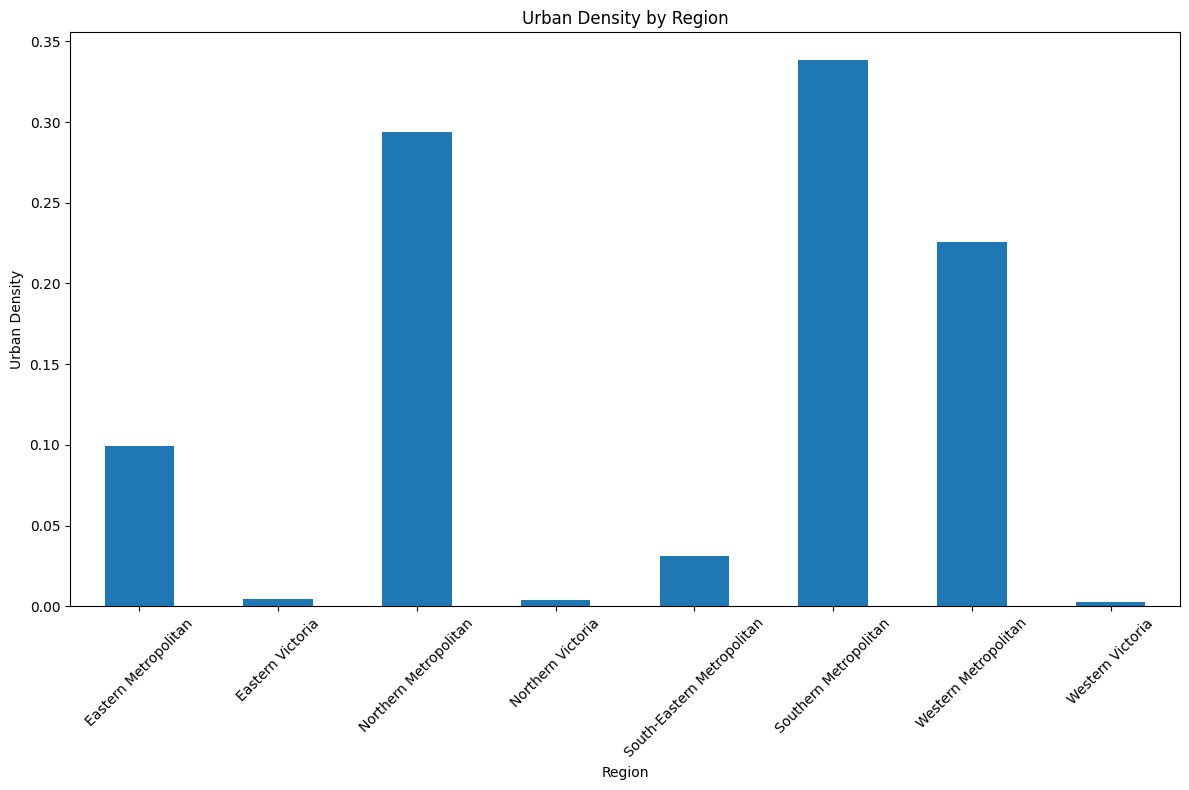

In [280]:
urban_density.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title("Urban Density by Region")
plt.xlabel("Region")
plt.ylabel("Urban Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

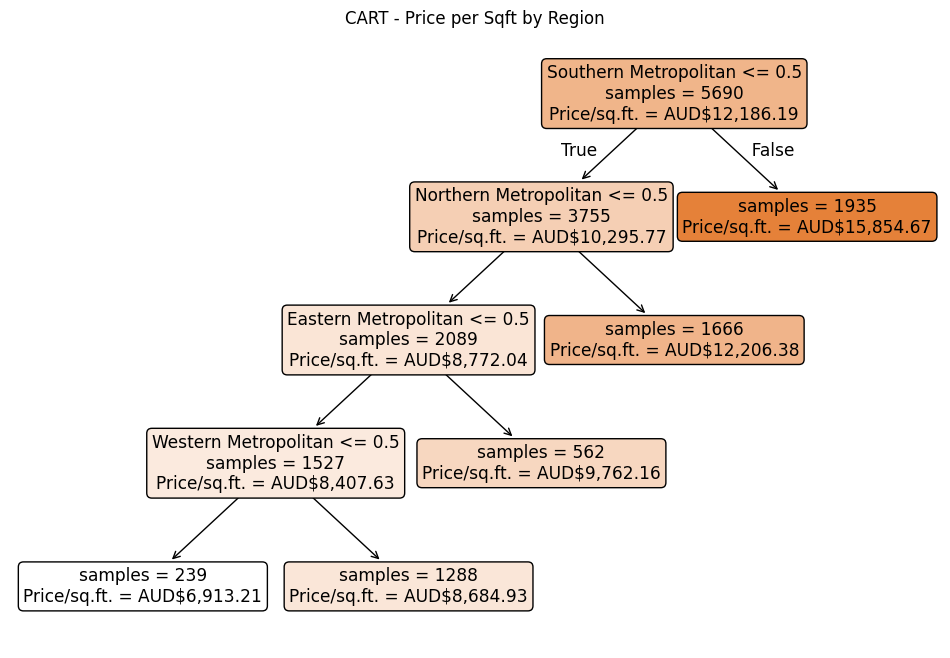

In [281]:
# CART
X = pd.get_dummies(house['Regionname'])
y_reg = house['price_per_sqft']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

cart = DecisionTreeRegressor(max_depth=4, random_state=42)
cart.fit(X_train, y_train)

import re
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(cart, feature_names=X.columns.tolist(), filled=True, rounded=True, impurity=False)
plt.title("CART - Price per Sqft by Region")

for text_obj in plt.gca().texts:
    updated = text_obj.get_text().replace("value =", "Price/sq.ft. =")
    updated = re.sub(r"Price/sq.ft. = (\d+\.\d+)",
                     lambda m: f"Price/sq.ft. = AUD${float(m.group(1)):,.2f}",
                     updated)
    text_obj.set_text(updated)

plt.show()

The Densest Regions tend to represent the highest prices.

In [282]:
# Naive-Bayes
house['price_tier'] = pd.qcut(house['price_per_sqft'], q=3, labels=['Low', 'Medium', 'High'])

t1 = pd.crosstab(house['Regionname'], house['price_tier'])
t1['Total'] = t1.sum(axis=1)
t1.loc['Total'] = t1.sum()
t1


price_tier,Low,Medium,High,Total
Regionname,,,,
Eastern Metropolitan,307,247,154,708
Eastern Victoria,27,3,0,30
Northern Metropolitan,757,662,671,2090
Northern Victoria,27,0,1,28
South-Eastern Metropolitan,132,64,24,220
Southern Metropolitan,251,914,1244,2409
Western Metropolitan,851,482,274,1607
Western Victoria,19,0,2,21
Total,2371,2372,2370,7113


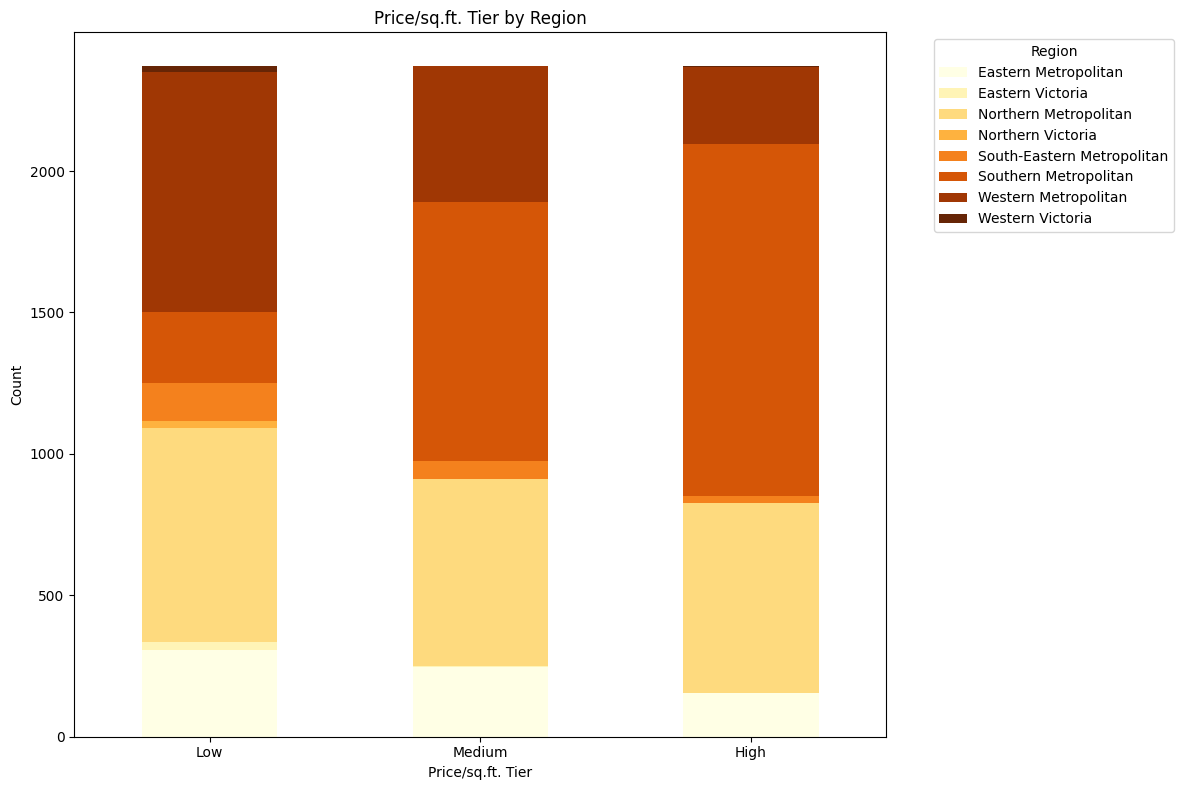

In [283]:
t1_plot = pd.crosstab(house['price_tier'], house['Regionname'])
t1_plot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='YlOrBr')
plt.title("Price/sq.ft. Tier by Region")
plt.xlabel("Price/sq.ft. Tier")
plt.ylabel("Count")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [284]:
X_price_ind = pd.get_dummies(house['price_tier'], drop_first=True).astype(float)
X_price_ind_dict = {i: col for i, col in enumerate(X_price_ind.columns)}

X_region_ind = pd.get_dummies(house['Regionname'], drop_first=True).astype(float)
X_region_ind_dict = {i: col for i, col in enumerate(X_region_ind.columns)}

X = pd.concat((X_price_ind, X_region_ind), axis=1)

print("Price tier mapping:", X_price_ind_dict)
print("Region mapping:", X_region_ind_dict)

Price tier mapping: {0: 'Medium', 1: 'High'}
Region mapping: {0: 'Eastern Victoria', 1: 'Northern Metropolitan', 2: 'Northern Victoria', 3: 'South-Eastern Metropolitan', 4: 'Southern Metropolitan', 5: 'Western Metropolitan', 6: 'Western Victoria'}


In [285]:
Y = house['price_tier']
X_train, X_test = train_test_split(X, test_size = 0.20, random_state = 42)
Y_train, Y_test = train_test_split(Y, test_size = 0.20, random_state = 42)

In [286]:
nb_01 = MultinomialNB().fit(X_train, Y_train)

Y_predicted = nb_01.predict(X_test)
Y_predicted = pd.crosstab(Y_test, Y_predicted, rownames=['Actual'], colnames=['Predicted']) #simplified with the help of Gemini AI
# Reverse the order of rows
Y_predicted = Y_predicted.iloc[::-1] #assisted by Gemini AI
Y_predicted['Total'] = Y_predicted.sum(axis=1); Y_predicted.loc['Total'] = Y_predicted.sum()
# Reorder columns to switch 'High' and 'Low'
new_column_order = ['High', 'Medium', 'Low', 'Total']  #assisted by Gemini AI
Y_predicted = Y_predicted[new_column_order] #assisted by Gemini AI

Y_predicted

Predicted,High,Medium,Low,Total
Actual,,,,
High,444,0,0,444
Medium,0,488,0,488
Low,118,0,373,491
Total,562,488,373,1423
